In [1]:
# Project root setup
import os
import sys
from pathlib import Path

ROOT = next((path for path in (Path.cwd(), *Path.cwd().parents) if (path / "src").is_dir()), None)
if ROOT is None:
    raise RuntimeError("Could not locate the project root containing src/.")
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

os.environ.setdefault("MPLCONFIGDIR", str(Path("/tmp") / "matplotlib"))
os.makedirs(os.environ["MPLCONFIGDIR"], exist_ok=True)


In [2]:
import importlib

import numpy as np
import pandas as pd
from IPython.display import Image, display

import synthetic.scripts.graph_size as gs

# Reload so notebook changes pick up the latest script version and current baselines.
gs = importlib.reload(gs)


/home/srey/Investigacion/cvx_dag_learning/.venv-dag/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Notebook controls. These override the defaults in synthetic/scripts/graph_size.py.
LOAD = True  # Set to False to rerun from the notebook.
SAVE = False
N_CPUS = gs.N_CPUS
JOBLIB_VERBOSE = gs.JOBLIB_VERBOSE

N_DAGS = gs.N_DAGS
THR = gs.THR
VERB = gs.VERB
SIZES = gs.SIZES
BASE_DATA_PARAMS = gs.BASE_DATA_PARAMS.copy()
JOINT_AGGS = gs.JOINT_AGGS
SELECTED_EXPERIMENT_LEGS = gs.SELECTED_EXPERIMENT_LEGS
SKIP_IDX = []  # Example: [2, 4] skips DAGMA and SortNRegress.

# Push notebook controls back into the script module used below.
gs.LOAD = LOAD
gs.SAVE = SAVE
gs.N_CPUS = N_CPUS
gs.JOBLIB_VERBOSE = JOBLIB_VERBOSE
gs.SKIP_IDX = SKIP_IDX


In [4]:
def display_png(path):
    path = Path(path)
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print(f"Missing figure: {path}")


def display_scenario_figures(suffix):
    display_png(Path(gs.PATH) / f"size_{suffix}_summary_mean.png")
    display_png(Path(gs.PATH) / f"size_{suffix}_summary_median.png")
    display_png(Path(gs.PATH) / f"size_{suffix}_all_metrics_mean.png")
    display_png(Path(gs.PATH) / f"size_{suffix}_all_metrics_median.png")


def display_joint_figures(aggs=JOINT_AGGS):
    for agg in aggs:
        display_png(Path(gs.PATH) / f"size_er_sf_joint_{agg}.png")


def scenario_result(scenario, metrics, exps, sizes):
    return {
        "scenario": scenario,
        "metrics": metrics,
        "exps": exps,
        "sizes": sizes,
    }


def _safe_stat(values, fn):
    values = np.asarray(values, dtype=float)
    if not np.isfinite(values).any():
        return np.nan
    return fn(values)


def metric_summary(metrics, exps, sizes):
    shd, _, _, _, err, acyc, runtime, dag_count = metrics
    rows = []
    for j, exp in enumerate(exps):
        for i, n_nodes in enumerate(sizes):
            shd_values = shd[:, i, j]
            rows.append({
                "n_nodes": int(n_nodes),
                "method": exp["leg"],
                "shd_mean": _safe_stat(shd_values, np.nanmean),
                "shd_median": _safe_stat(shd_values, np.nanmedian),
                "err_mean": _safe_stat(err[:, i, j], np.nanmean),
                "err_median": _safe_stat(err[:, i, j], np.nanmedian),
                "dag_rate": _safe_stat(dag_count[:, i, j], np.nanmean),
                "acyc_mean": _safe_stat(acyc[:, i, j], np.nanmean),
                "time_median": _safe_stat(runtime[:, i, j], np.nanmedian),
                "n_completed": int(np.isfinite(shd_values).sum()),
            })
    return pd.DataFrame(rows)


def _completed_size_mask(scenario, sizes):
    file_name = Path(f"{gs.size_results_prefix(scenario)}.npz")
    if not file_name.exists():
        return np.ones(len(sizes), dtype=bool)

    data = np.load(file_name, allow_pickle=True)
    if "completed_sizes" in data.files and len(data["completed_sizes"]):
        completed = {int(size) for size in data["completed_sizes"]}
        return np.asarray([int(size) in completed for size in sizes], dtype=bool)

    if "shd" in data.files:
        return np.isfinite(data["shd"]).any(axis=(0, 2))

    return np.ones(len(sizes), dtype=bool)


def trim_to_completed_sizes(metrics, sizes, scenario):
    mask = _completed_size_mask(scenario, sizes)
    if mask.all():
        return metrics, sizes

    trimmed_sizes = np.asarray(sizes)[mask]
    trimmed_metrics = tuple(metric[:, mask, :] for metric in metrics)
    skipped = np.asarray(sizes)[~mask]
    print(f"Skipping incomplete sizes for {scenario['name']}: {skipped.tolist()}")
    return trimmed_metrics, trimmed_sizes


def align_scenario_results(scenario_results):
    if not scenario_results:
        return []

    common = set(int(size) for size in scenario_results[0]["sizes"])
    for result in scenario_results[1:]:
        common &= {int(size) for size in result["sizes"]}

    reference = [int(size) for size in scenario_results[0]["sizes"]]
    common_ordered = [size for size in reference if size in common]
    if not common_ordered:
        print("No common completed sizes for joint plots.")
        return []

    aligned = []
    for result in scenario_results:
        mask = np.asarray([int(size) in common_ordered for size in result["sizes"]], dtype=bool)
        aligned.append({
            **result,
            "metrics": tuple(metric[:, mask, :] for metric in result["metrics"]),
            "sizes": np.asarray(result["sizes"])[mask],
        })

    if any(len(result["sizes"]) != len(scenario_results[0]["sizes"]) for result in aligned):
        print("Joint plots use common completed sizes:", common_ordered)

    return aligned


In [5]:
sizes = np.asarray(SIZES)
scenarios = gs.build_scenarios(BASE_DATA_PARAMS)

print("Scenarios:", [scenario["name"] for scenario in scenarios])
for scenario in scenarios:
    exps = gs.filter_experiments(
        gs.build_experiments_for_scenario(scenario["suffix"]),
        SELECTED_EXPERIMENT_LEGS,
    )
    print(f"Baselines for {scenario['name']}:")
    for i, exp in enumerate(exps):
        skipped = " (skipped)" if i in SKIP_IDX else ""
        print(f"  {i}: {exp['leg']}{skipped}")
print("Size grid:", sizes)
print("Mode:", "load" if LOAD else "run")
print("Results path:", gs.PATH)


Scenarios: ['Erdos-Renyi', 'Scale-free']
Baselines for Erdos-Renyi:
  0: NOMAD-adam
  1: NOMAD-fista
  2: DAGMA
  3: NonDAGMA
  4: SortNRegress
Baselines for Scale-free:
  0: NOMAD-adam
  1: NOMAD-fista
  2: DAGMA
  3: NonDAGMA
  4: SortNRegress
Size grid: [  50   75  100  250  500 1000]
Mode: load
Results path: /home/srey/Investigacion/cvx_dag_learning/results/size/


## Erdos-Renyi Scenario


Loaded size results from /home/srey/Investigacion/cvx_dag_learning/results/size/size_ERgraph_4N_1w.npz


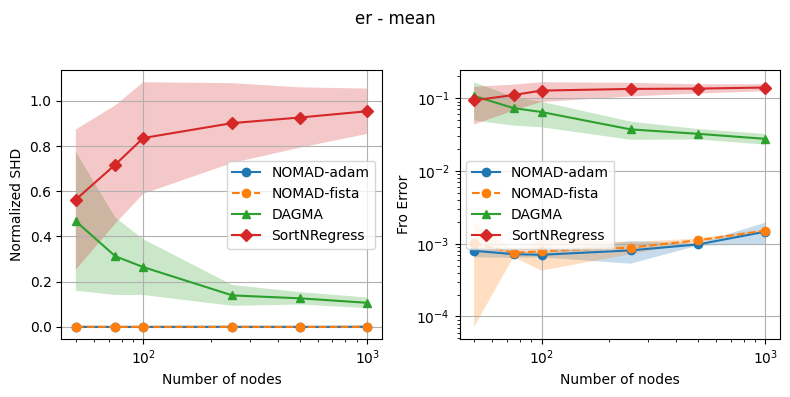

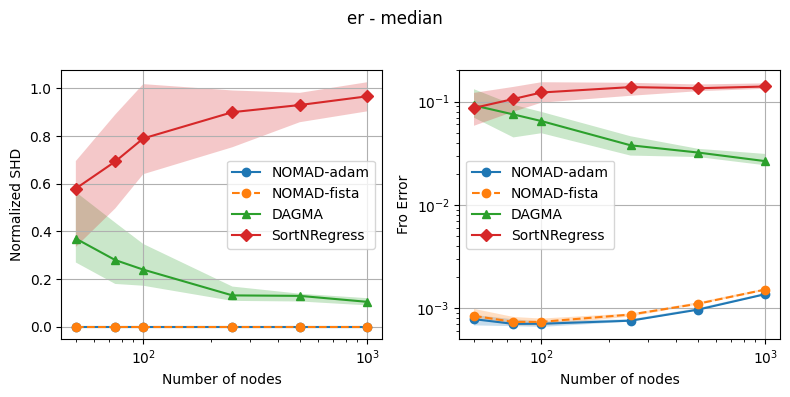

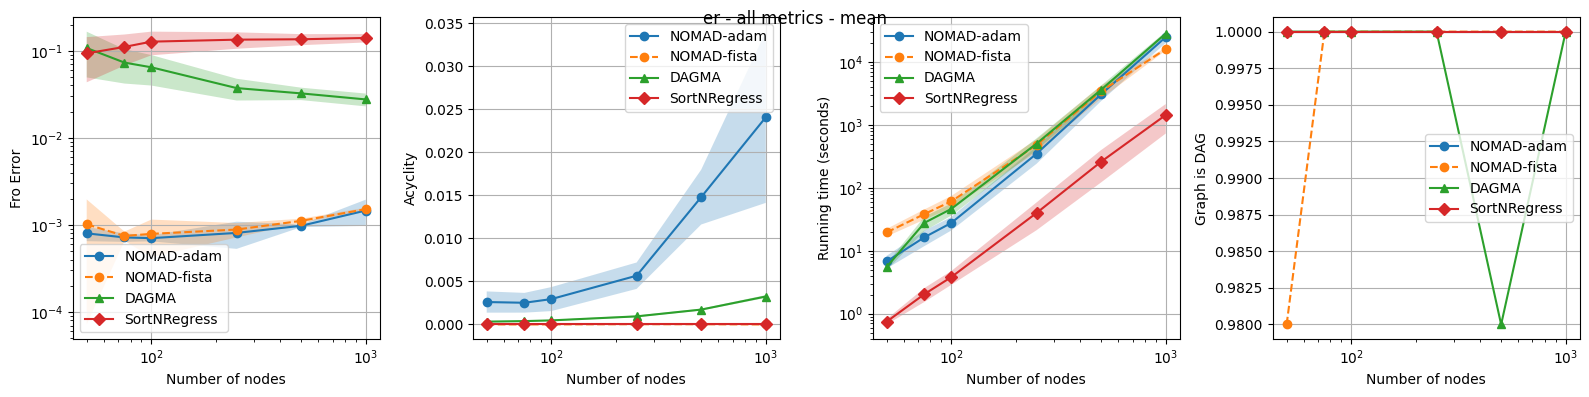

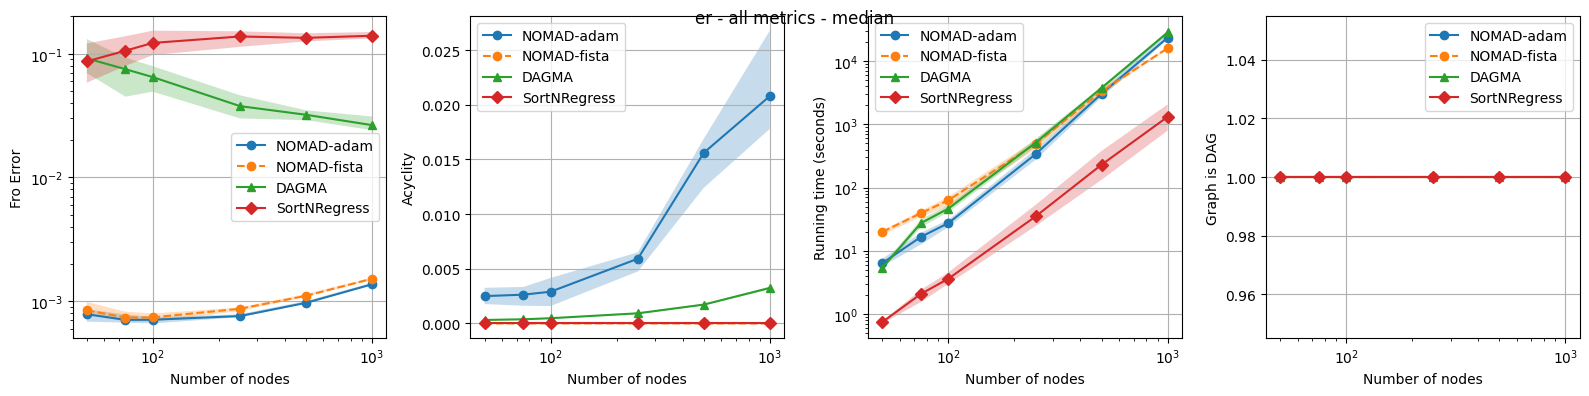

,n_nodes,method,shd_mean,shd_median,err_mean,err_median,dag_rate,acyc_mean,time_median,n_completed
0,50,NOMAD-adam,0.000000,0.000000,0.000800,0.000784,1.00,0.002606,6.418864,50
1,75,NOMAD-adam,0.000000,0.000000,0.000719,0.000706,1.00,0.002522,16.675935,50
2,100,NOMAD-adam,0.000000,0.000000,0.000705,0.000707,1.00,0.002947,27.527674,50
3,250,NOMAD-adam,0.000400,0.000000,0.000810,0.000758,1.00,0.005666,338.716463,50
4,500,NOMAD-adam,0.000000,0.000000,0.000978,0.000969,1.00,0.014793,3056.817494,50
5,1000,NOMAD-adam,0.000760,0.000000,0.001464,0.001368,1.00,0.024067,23535.122101,50
6,50,NOMAD-fista,0.000800,0.000000,0.001017,0.000843,0.98,0.000009,20.009138,50
7,75,NOMAD-fista,0.000000,0.000000,0.000748,0.000737,1.00,0.000005,39.555799,50
8,100,NOMAD-fista,0.000200,0.000000,0.000789,0.000738,1.00,0.000011,63.182687,50
9,250,NOMAD-fista,0.000080,0.000000,0.000885,0.000868,1.00,0.000034,493.115048,50


In [9]:
er_scenario = scenarios[0]
er_exps = gs.filter_experiments(
    gs.build_experiments_for_scenario(er_scenario["suffix"]),
    SELECTED_EXPERIMENT_LEGS,
)

er_shd, er_tpr, er_fdr, er_fscore, er_err, er_acyc, er_runtime, er_dag_count, er_exps, er_sizes = gs.run_or_load_size_results(
    er_scenario,
    sizes,
    er_exps,
    N_DAGS,
    thr=THR,
    verb=VERB,
)

SKIP_IDX = [3]

er_metrics = (er_shd, er_tpr, er_fdr, er_fscore, er_err, er_acyc, er_runtime, er_dag_count)
er_metrics, er_sizes = trim_to_completed_sizes(er_metrics, er_sizes, er_scenario)

gs.plot_results(er_metrics, er_exps, er_sizes, er_scenario["suffix"], skip_idx=SKIP_IDX)
display_scenario_figures(er_scenario["suffix"])

er_summary = metric_summary(er_metrics, er_exps, er_sizes)
display(er_summary)


## Scale-Free Scenario


Loaded size results from /home/srey/Investigacion/cvx_dag_learning/results/size/size_SFgraph_4N_1w.npz


Skipping incomplete sizes for Scale-free: [1000]


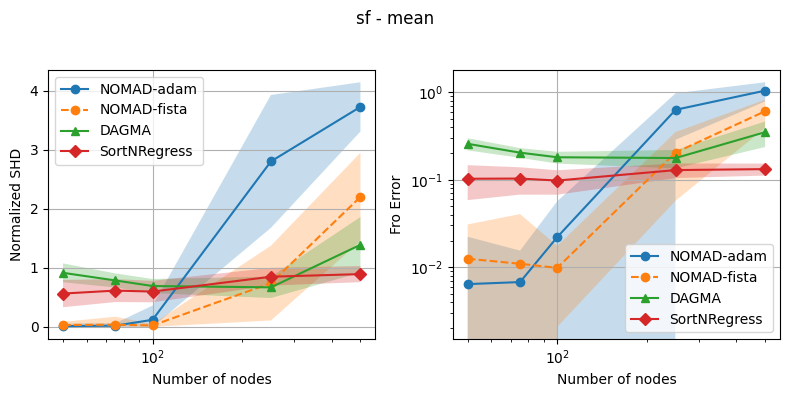

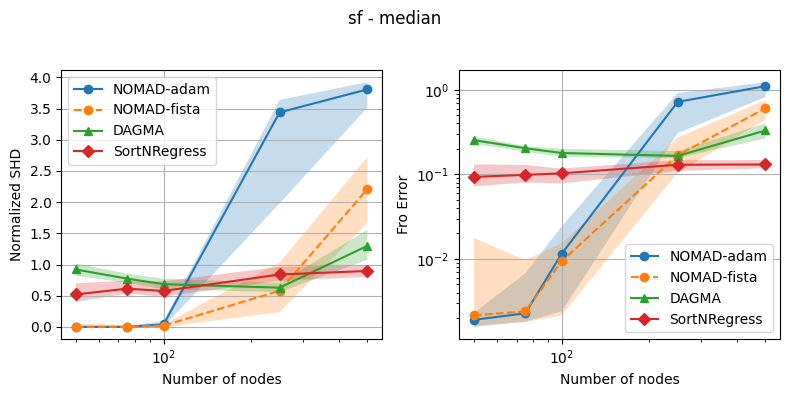

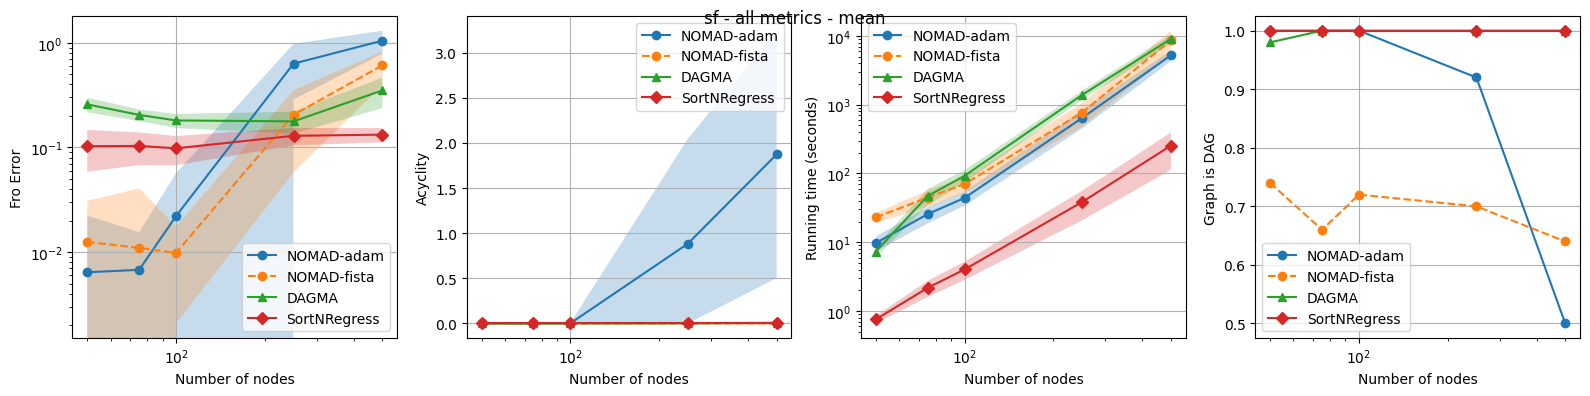

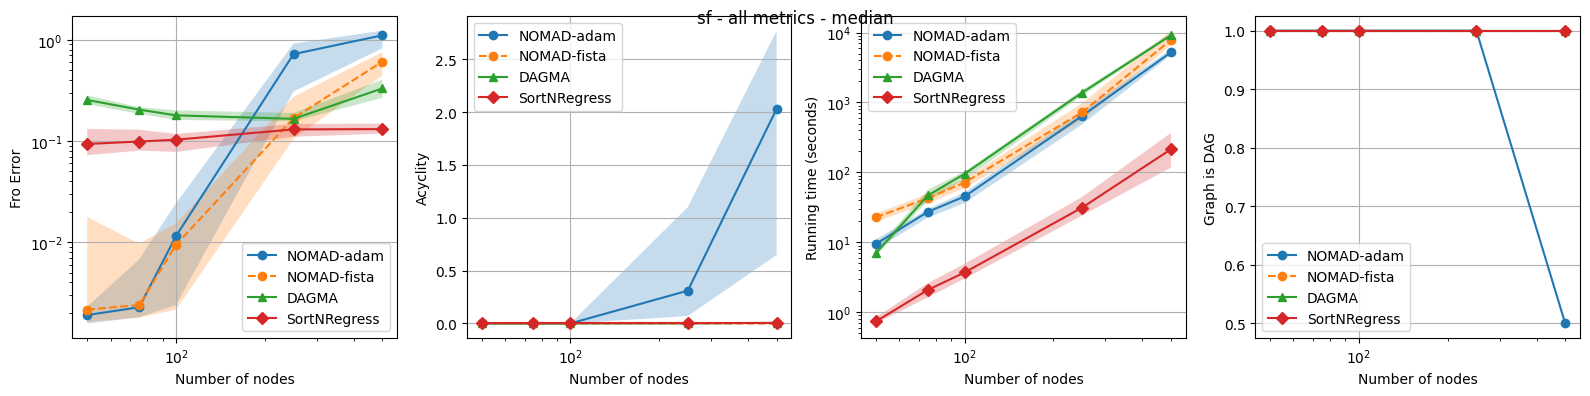

,n_nodes,method,shd_mean,shd_median,err_mean,err_median,dag_rate,acyc_mean,time_median,n_completed
0,50,NOMAD-adam,0.013200,0.000000,0.006407,0.001904,1.00,0.001904,9.492177,50
1,75,NOMAD-adam,0.020533,0.000000,0.006759,0.002274,1.00,0.001252,27.258374,50
2,100,NOMAD-adam,0.120400,0.040000,0.022086,0.011515,1.00,0.002040,45.349205,50
3,250,NOMAD-adam,2.802400,3.438000,0.631632,0.720828,0.92,0.883203,643.300579,50
4,500,NOMAD-adam,3.726520,3.807000,1.046639,1.106292,0.50,1.872649,5221.516018,50
5,50,NOMAD-fista,0.032400,0.000000,0.012490,0.002154,0.74,0.000016,22.807120,50
6,75,NOMAD-fista,0.036800,0.000000,0.010950,0.002396,0.66,0.000019,42.753957,50
7,100,NOMAD-fista,0.024600,0.020000,0.009817,0.009408,0.72,0.000015,71.677987,50
8,250,NOMAD-fista,0.741840,0.578000,0.204800,0.168267,0.70,0.000128,723.829731,50
9,500,NOMAD-fista,2.202280,2.209000,0.608368,0.606313,0.64,0.000368,7843.969280,50


In [10]:
sf_scenario = scenarios[1]
sf_exps = gs.filter_experiments(
    gs.build_experiments_for_scenario(sf_scenario["suffix"]),
    SELECTED_EXPERIMENT_LEGS,
)

sf_shd, sf_tpr, sf_fdr, sf_fscore, sf_err, sf_acyc, sf_runtime, sf_dag_count, sf_exps, sf_sizes = gs.run_or_load_size_results(
    sf_scenario,
    sizes,
    sf_exps,
    N_DAGS,
    thr=THR,
    verb=VERB,
)

SKIP_IDX = [3]

sf_metrics = (sf_shd, sf_tpr, sf_fdr, sf_fscore, sf_err, sf_acyc, sf_runtime, sf_dag_count)
sf_metrics, sf_sizes = trim_to_completed_sizes(sf_metrics, sf_sizes, sf_scenario)

gs.plot_results(sf_metrics, sf_exps, sf_sizes, sf_scenario["suffix"], skip_idx=SKIP_IDX)
display_scenario_figures(sf_scenario["suffix"])

sf_summary = metric_summary(sf_metrics, sf_exps, sf_sizes)
display(sf_summary)


## Joint Scenario Plots


Joint plots use common completed sizes: [50, 75, 100, 250, 500]


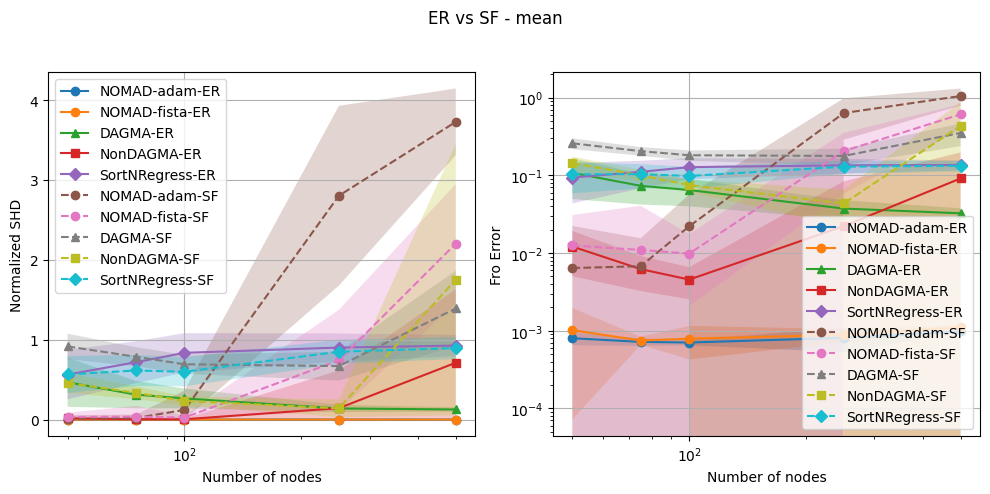

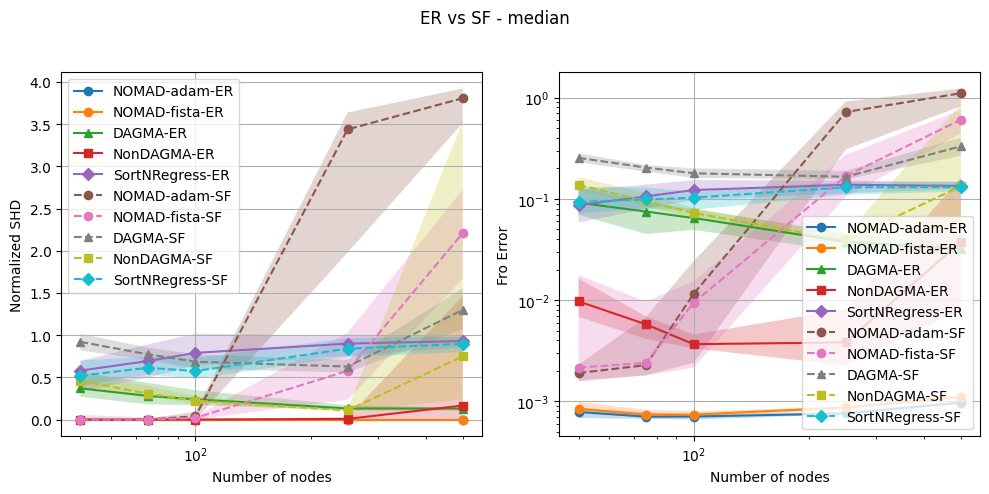

In [8]:
scenario_results = [
    scenario_result(er_scenario, er_metrics, er_exps, er_sizes),
    scenario_result(sf_scenario, sf_metrics, sf_exps, sf_sizes),
]

joint_results = align_scenario_results(scenario_results)
for agg in JOINT_AGGS:
    gs.plot_joint_results(joint_results, agg=agg, skip_idx=SKIP_IDX)

display_joint_figures()
